# Exploration des données (EDA) : Telco Customer Churn

**Objectif :** comprendre les données et repérer les problèmes **avant** le prétraitement.
Dans ce notebook, on **regarde** les données, on ne les modifie pas (hors conversions nécessaires pour analyser).

Plan :
1. Vue d'ensemble
2. Qualité des données
3. Cible (`Churn`)
4. Variables numériques
5. Matrice de corrélation
6. Variables catégorielles (taux de churn par modalité)
7. Analyses croisées
8. Synthèse

In [1]:
import os, sys
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Se placer à la racine du projet (pour importer src/ et trouver data/)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.append(os.getcwd())

from src.data import load_data, clean

pd.set_option("display.max_columns", 50)
TEMPLATE = "plotly_white"

## 1. Vue d'ensemble

In [2]:
df_raw = load_data()          # données brutes, telles que téléchargées
print("Taille (lignes, colonnes) :", df_raw.shape)
df_raw.head()

Taille (lignes, colonnes) : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Statistiques des variables numériques
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Statistiques des variables catégorielles (nombre de modalités, modalité la plus fréquente...)
df_raw.describe(include="object").T

C:\Users\mpshop\AppData\Local\Temp\ipykernel_33972\1506465871.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object").T


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


**À noter :** `TotalCharges` apparaît en type `object` (texte) alors qu'elle devrait être numérique. Premier problème détecté.
`SeniorCitizen` est en 0/1 : c'est en réalité une variable catégorielle binaire.

## 2. Qualité des données

In [6]:
# 2.1 Valeurs manquantes "classiques"
na = df_raw.isna().sum()
print("NaN classiques :", int(na.sum()))
na[na > 0]

NaN classiques : 0


Series([], dtype: int64)

In [7]:
# 2.2 Valeurs manquantes CACHÉES : chaînes vides ou espaces
blank = df_raw.select_dtypes("object").apply(lambda s: s.str.strip() == "").sum()
blank = blank[blank > 0]
print("Colonnes avec des espaces vides :")
blank

C:\Users\mpshop\AppData\Local\Temp\ipykernel_33972\1901268340.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  blank = df_raw.select_dtypes("object").apply(lambda s: s.str.strip() == "").sum()


Colonnes avec des espaces vides :


TotalCharges    11
dtype: int64

In [8]:
# 2.3 Conversion de TotalCharges et vérification des lignes concernées
total_num = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
mask = total_num.isna()
print("Nombre de TotalCharges non convertibles :", mask.sum())
df_raw.loc[mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Nombre de TotalCharges non convertibles : 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
# Ces clients ont-ils tous tenure == 0 ? (justifie l'imputation par 0)
print("Tous ont tenure = 0 :", (df_raw.loc[mask, "tenure"] == 0).all())

Tous ont tenure = 0 : True


In [10]:
# 2.4 Doublons
print("Lignes dupliquées (toutes colonnes) :", df_raw.duplicated().sum())
print("customerID unique :", df_raw["customerID"].is_unique)
print("Doublons hors customerID :", df_raw.drop(columns="customerID").duplicated().sum())

Lignes dupliquées (toutes colonnes) : 0
customerID unique : True
Doublons hors customerID : 22


**Lecture :** les doublons hors `customerID` sont de simples clients au profil identique (peu de variables continues),
ce ne sont pas des erreurs : on **ne les supprime pas**. `customerID` est unique : c'est un identifiant, il sera supprimé.

In [11]:
# Jeu nettoyé pour la suite de l'analyse (drop customerID, TotalCharges numérique, Churn en 0/1)
df = clean(df_raw)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df.columns if c not in num_cols + ["Churn", "SeniorCitizen"]]
print("Numériques :", num_cols)
print("Catégorielles (%d) :" % len(cat_cols), cat_cols)

Numériques : ['tenure', 'MonthlyCharges', 'TotalCharges']
Catégorielles (15) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 3. La cible : `Churn`

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


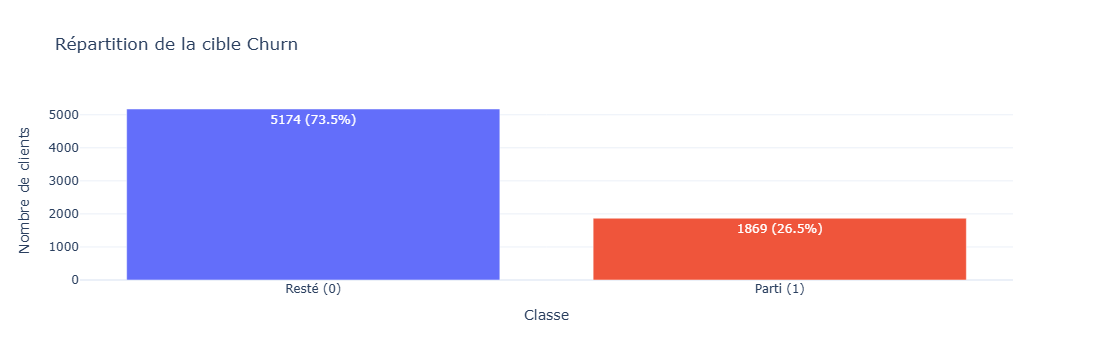

In [12]:
counts = df["Churn"].value_counts().rename({0: "Resté (0)", 1: "Parti (1)"})
print(df["Churn"].value_counts(normalize=True).round(3))

fig = px.bar(x=counts.index, y=counts.values, text=[f"{v} ({v/len(df):.1%})" for v in counts.values],
             color=counts.index, title="Répartition de la cible Churn", template=TEMPLATE,
             labels={"x": "Classe", "y": "Nombre de clients"})
fig.update_layout(showlegend=False)
fig.show()

**Lecture :** environ 73 % / 27 %. Classes **déséquilibrées** : un modèle qui répond toujours « reste » aurait 73 % d'accuracy.
On utilisera donc AUC, PR-AUC, rappel et F1, et `class_weight="balanced"`.

## 4. Variables numériques

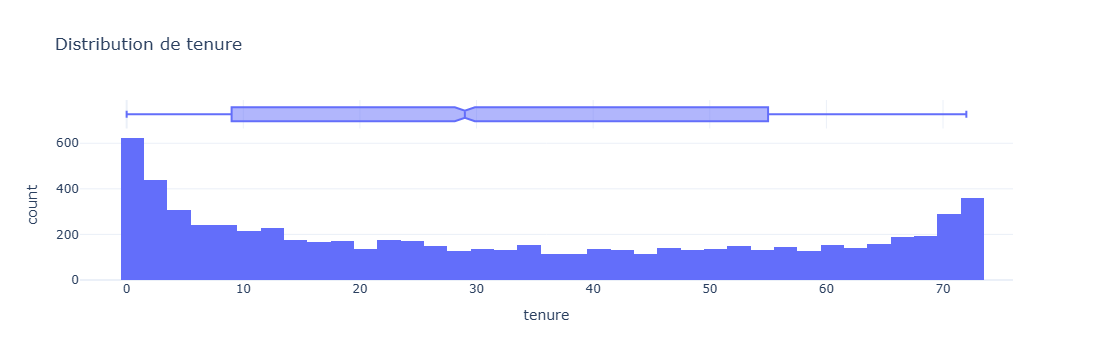

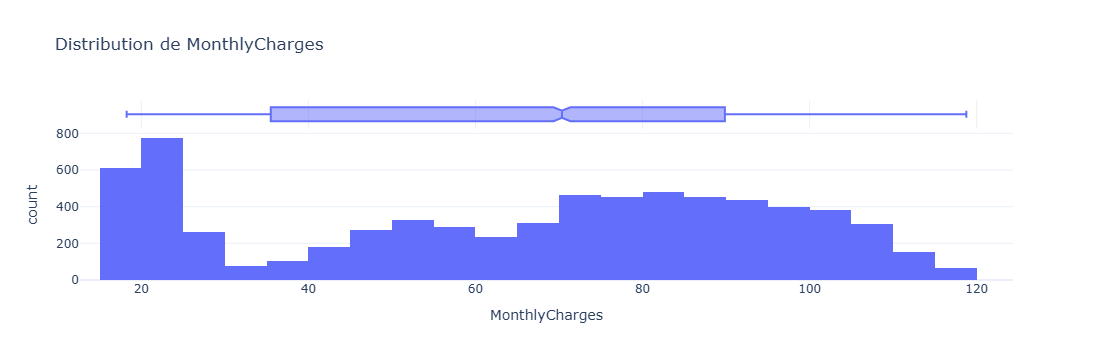

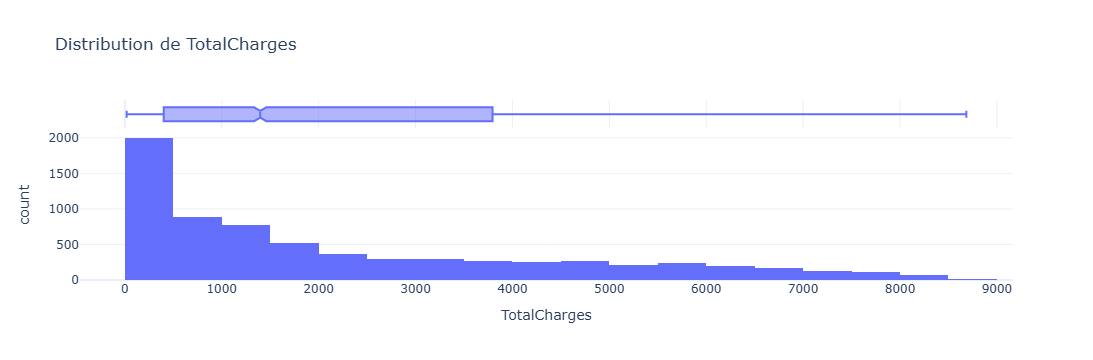

In [13]:
# 4.1 Histogrammes (global)
for col in num_cols:
    fig = px.histogram(df, x=col, nbins=40, marginal="box", template=TEMPLATE,
                       title=f"Distribution de {col}")
    fig.show()

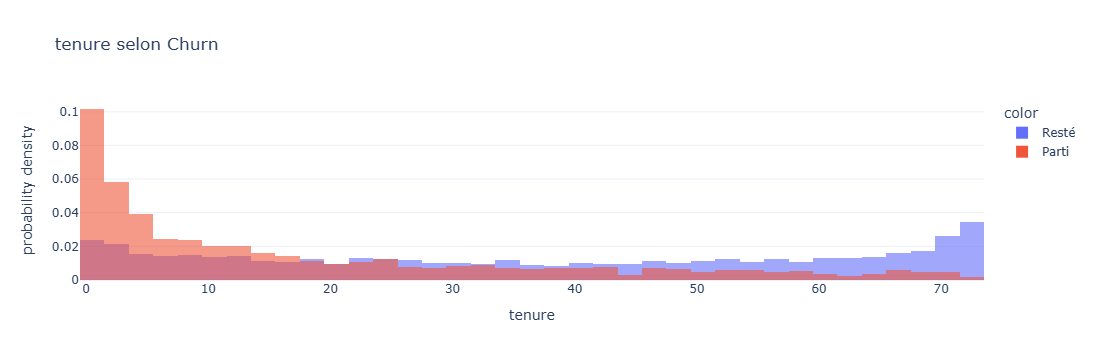

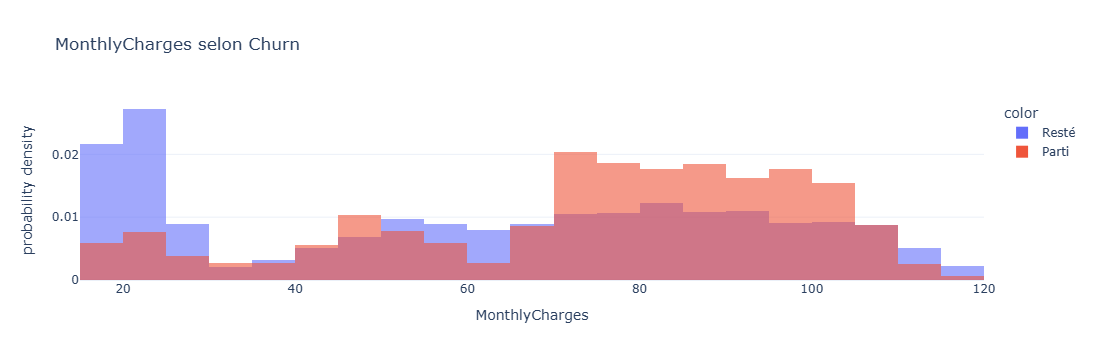

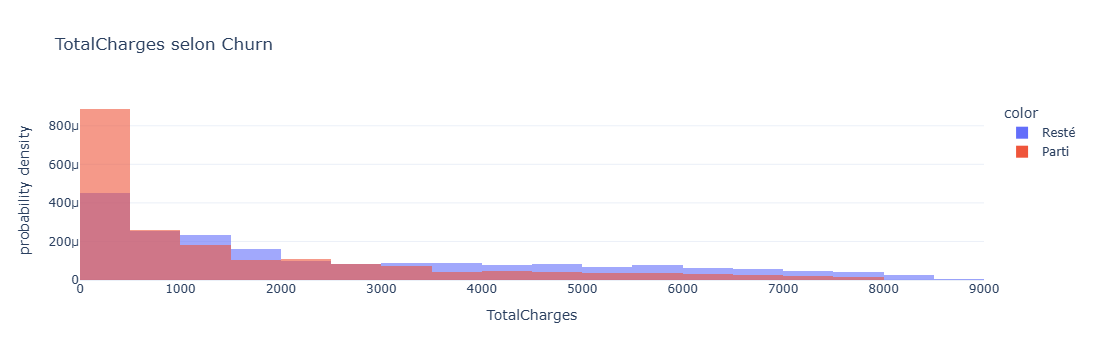

In [14]:
# 4.2 Distribution par classe de Churn (histogrammes superposés)
for col in num_cols:
    fig = px.histogram(df, x=col, color=df["Churn"].map({0: "Resté", 1: "Parti"}), nbins=40,
                       barmode="overlay", opacity=0.6, histnorm="probability density",
                       template=TEMPLATE, title=f"{col} selon Churn")
    fig.show()

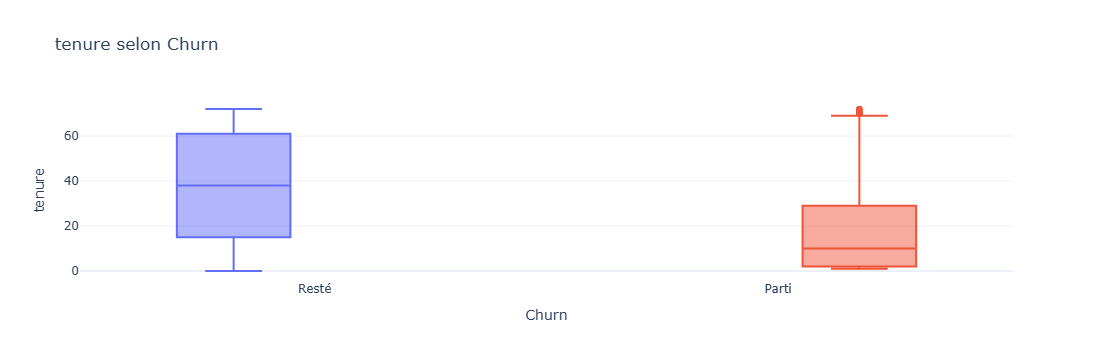

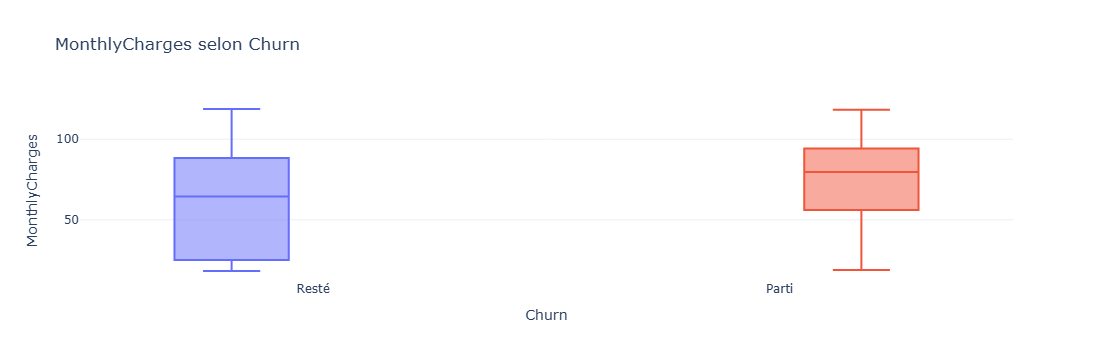

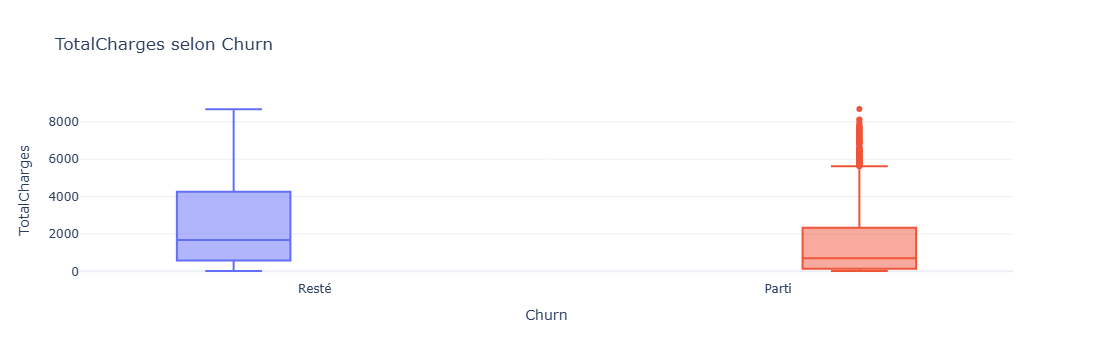

In [15]:
# 4.3 Boxplots par classe de Churn
for col in num_cols:
    fig = px.box(df, x=df["Churn"].map({0: "Resté", 1: "Parti"}), y=col,
                 color=df["Churn"].map({0: "Resté", 1: "Parti"}), template=TEMPLATE,
                 title=f"{col} selon Churn", labels={"x": "Churn"})
    fig.update_layout(showlegend=False)
    fig.show()

In [16]:
# 4.4 Moyennes / médianes par classe
df.groupby("Churn")[num_cols].agg(["mean", "median"]).round(1)

tenure        MonthlyCharges        TotalCharges        
        mean median           mean median         mean  median
Churn                                                         
0       37.6   38.0           61.3   64.4       2555.3  1683.6
1       18.0   10.0           74.4   79.6       1531.8   703.6

**À observer :**
- `tenure` : distribution **en U** (beaucoup de nouveaux et beaucoup de très anciens clients) ; les clients partis ont une ancienneté bien plus faible.
- `MonthlyCharges` : plus élevée chez les clients partis.
- `TotalCharges` : très asymétrique (étalée à droite) ; plus faible chez les partis, simplement parce qu'ils sont moins anciens.

## 5. Matrice de corrélation

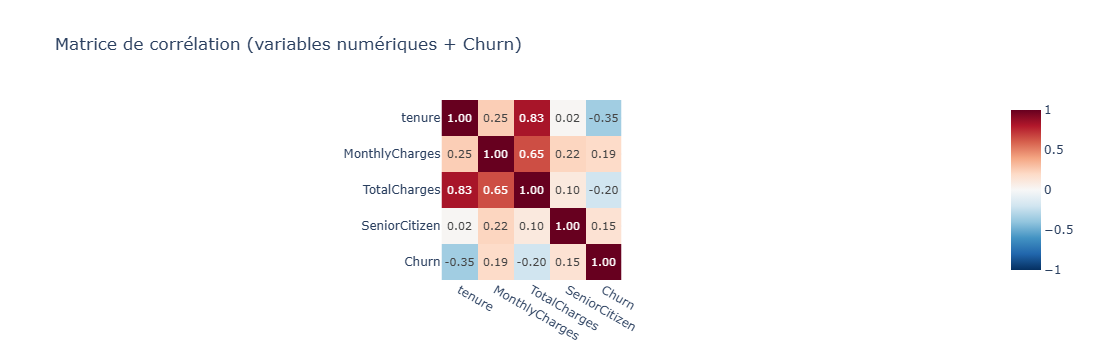

In [17]:
corr_cols = num_cols + ["SeniorCitizen", "Churn"]
corr = df[corr_cols].corr()

fig = px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
                title="Matrice de corrélation (variables numériques + Churn)", template=TEMPLATE)
fig.show()

In [18]:
# Corrélations avec la cible, triées
corr["Churn"].drop("Churn").sort_values()

tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Name: Churn, dtype: float64

corr(tenure, TotalCharges) = 0.826


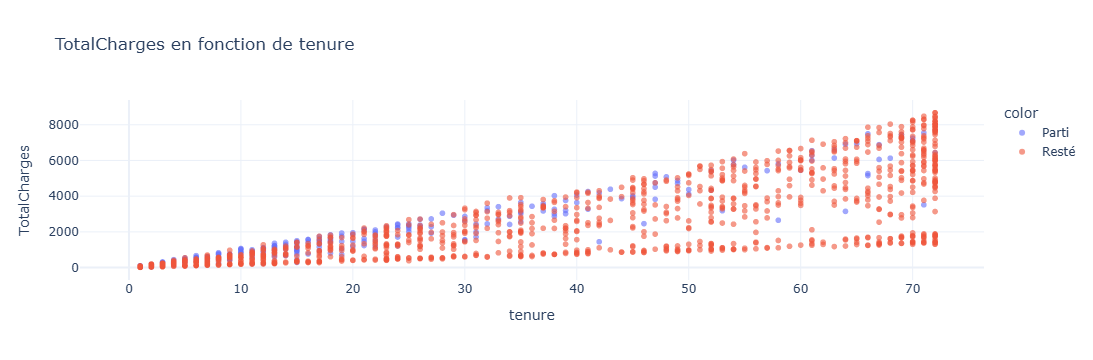

In [19]:
# Redondance tenure / TotalCharges
print("corr(tenure, TotalCharges) =", round(df["tenure"].corr(df["TotalCharges"]), 3))
sample = df.sample(1500, random_state=42)
fig = px.scatter(sample, x="tenure", y="TotalCharges",
                 color=sample["Churn"].map({0: "Resté", 1: "Parti"}), opacity=0.6, template=TEMPLATE,
                 title="TotalCharges en fonction de tenure")
fig.show()

**Lecture :** `tenure` et `TotalCharges` sont fortement corrélées (~0,83) : `TotalCharges` ≈ `tenure × MonthlyCharges`.
C'est de la **redondance** : elle peut brouiller l'interprétation SHAP (l'importance se répartit entre les deux).
Décision à prendre au prétraitement : garder les deux, ou en retirer une (à tester).
`tenure` est négativement corrélée à `Churn` : plus le client est ancien, moins il part.

## 6. Variables catégorielles : taux de churn par modalité

In [20]:
global_rate = df["Churn"].mean()
print(f"Taux de churn global : {global_rate:.1%}")

rows = []
for col in cat_cols + ["SeniorCitizen"]:
    g = df.groupby(col)["Churn"].agg(["mean", "count"]).reset_index()
    g.columns = ["modalite", "taux_churn", "effectif"]
    g.insert(0, "variable", col)
    rows.append(g)
rates = pd.concat(rows, ignore_index=True)
rates["ecart_vs_moyenne"] = (rates["taux_churn"] - global_rate).round(3)
rates["modalite"] = rates["modalite"].astype(str)
rates.sort_values("taux_churn", ascending=False).head(15)

Taux de churn global : 26.5%


,variable,modalite,taux_churn,effectif,ecart_vs_moyenne
39,PaymentMethod,Electronic check,0.452854,2365,0.187
32,Contract,Month-to-month,0.427097,3875,0.162
12,InternetService,Fiber optic,0.418928,3096,0.154
14,OnlineSecurity,No,0.417667,3498,0.152
42,SeniorCitizen,1,0.416813,1142,0.151
23,TechSupport,No,0.416355,3473,0.151
17,OnlineBackup,No,0.399288,3088,0.134
20,DeviceProtection,No,0.391276,3095,0.126
29,StreamingMovies,No,0.336804,2785,0.071
36,PaperlessBilling,Yes,0.335651,4171,0.070


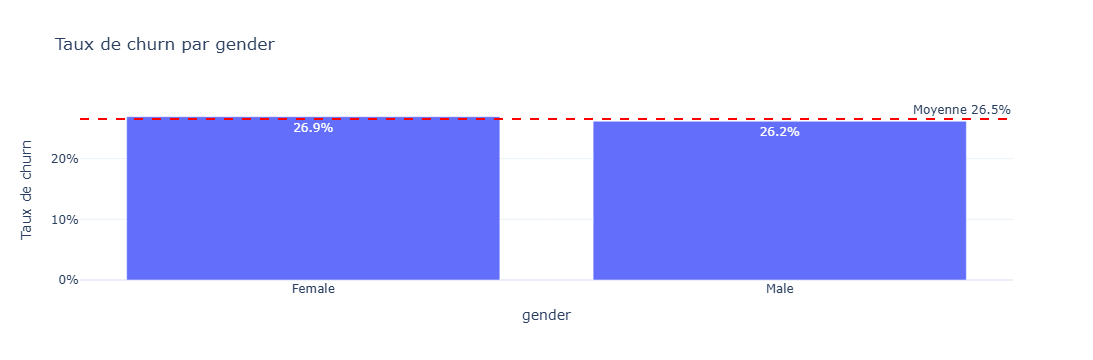

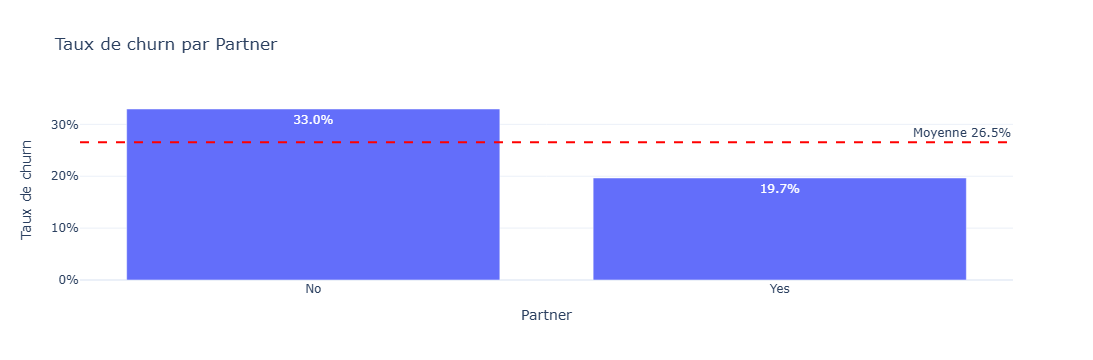

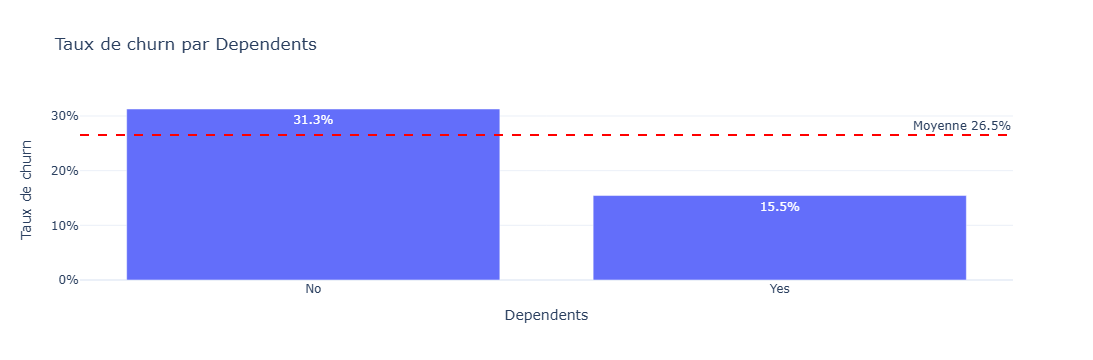

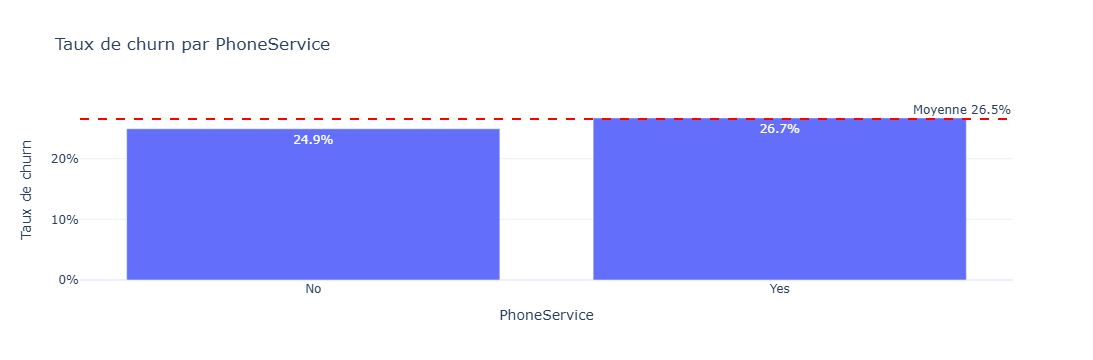

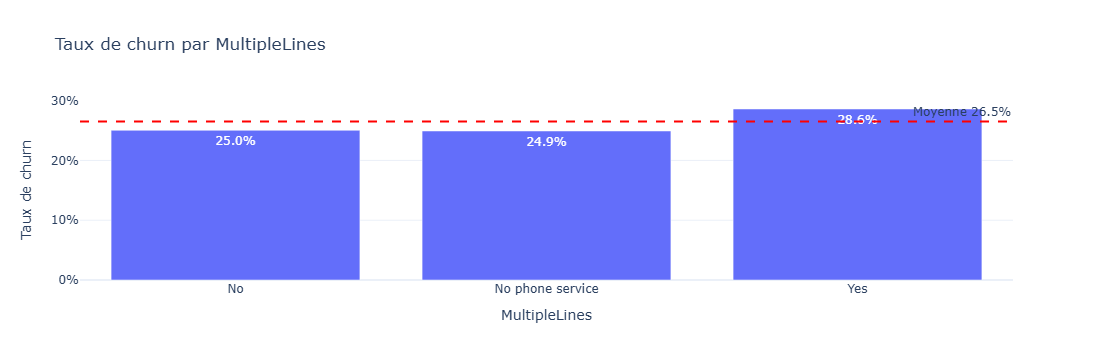

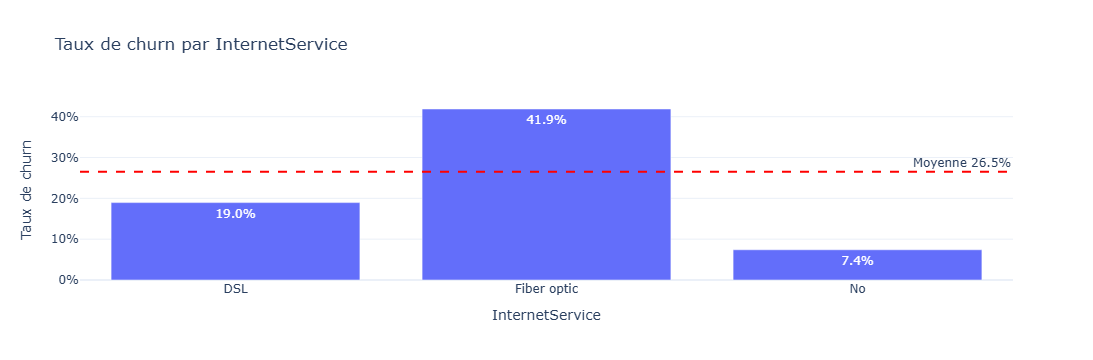

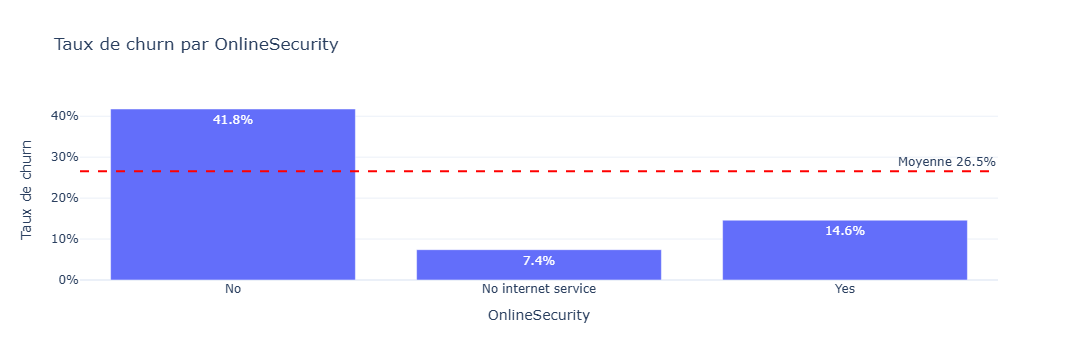

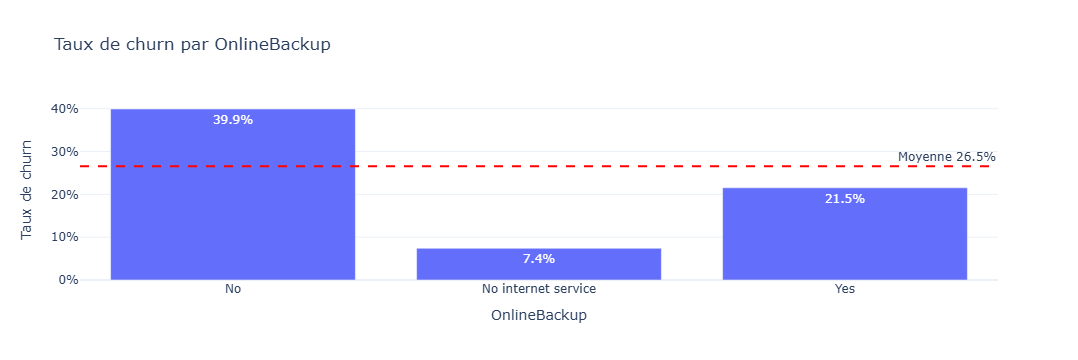

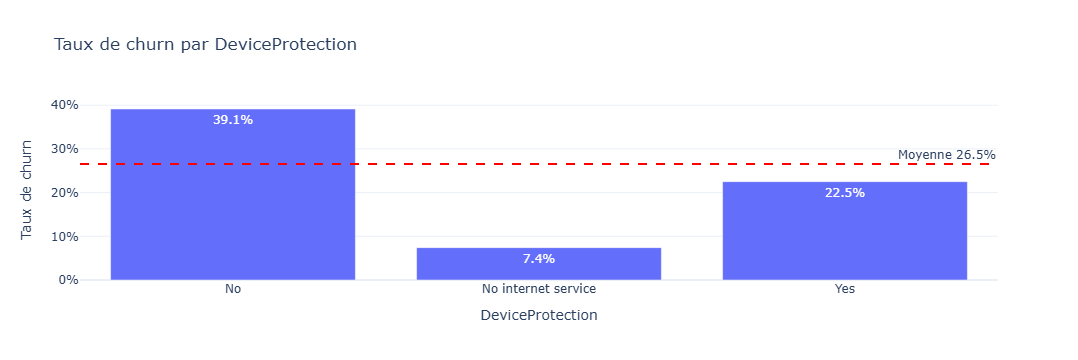

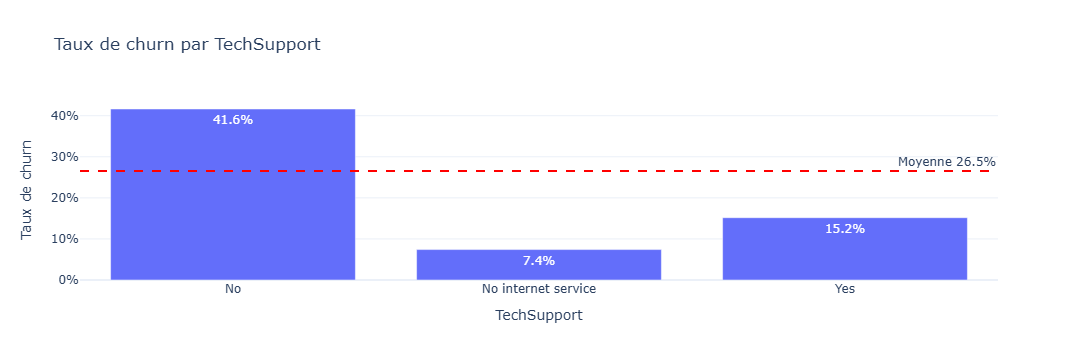

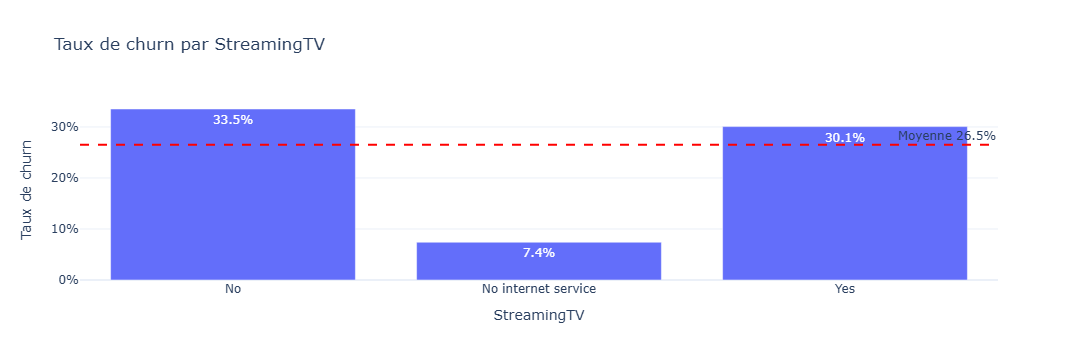

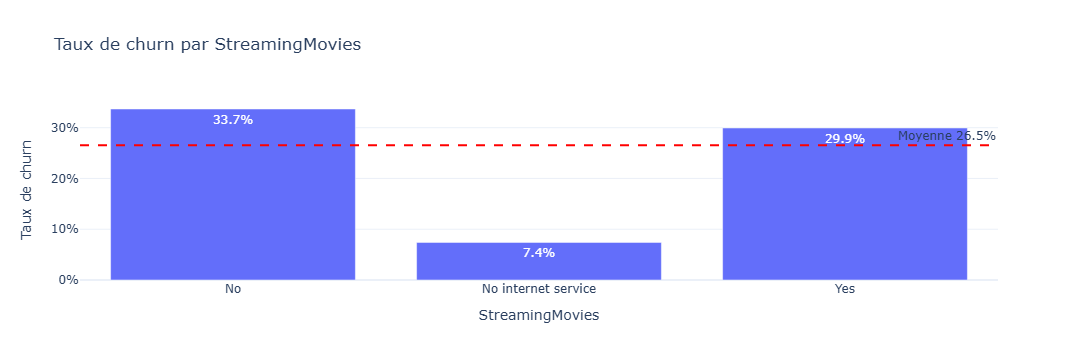

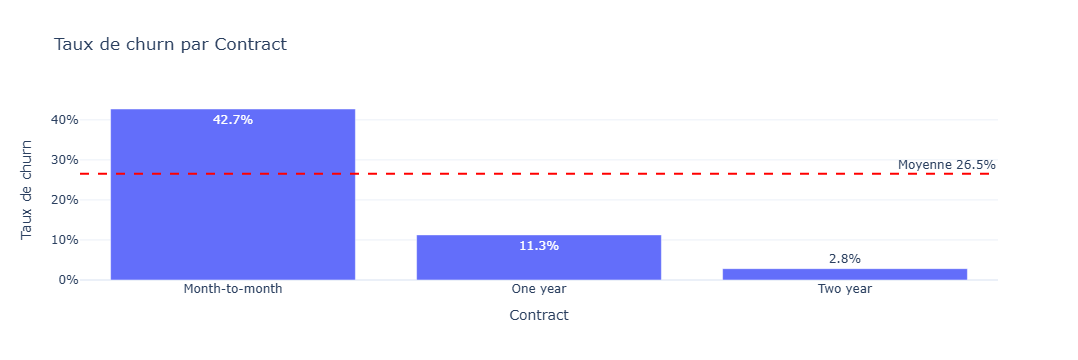

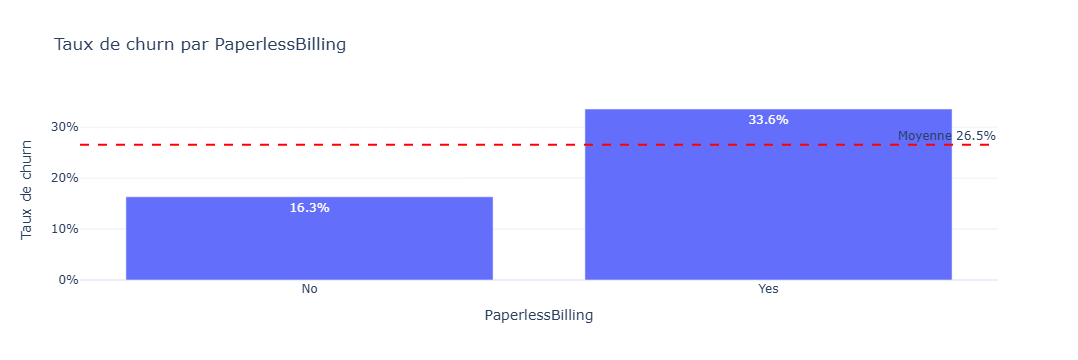

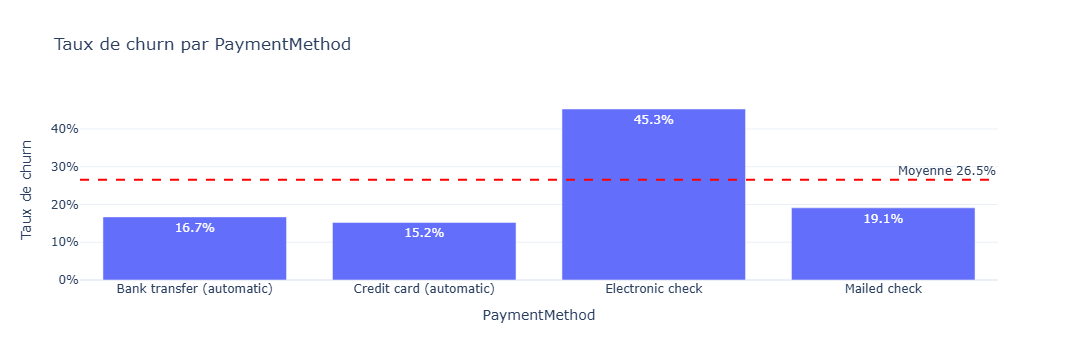

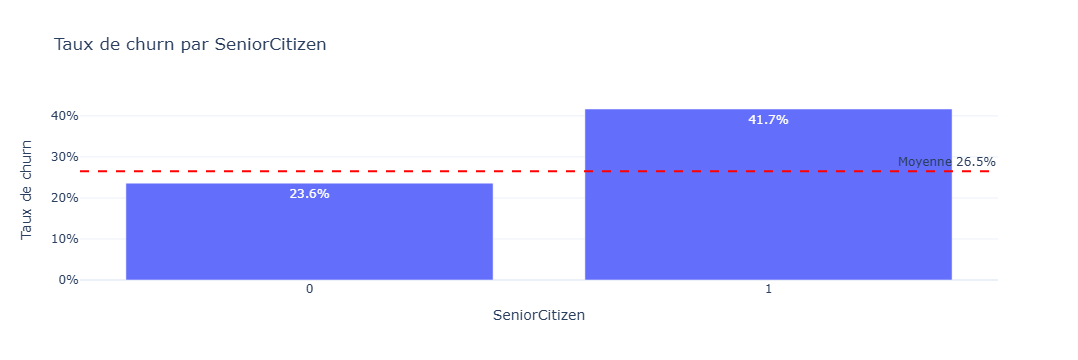

In [21]:
# Un graphique par variable : barres + ligne de la moyenne globale
def plot_rate(col):
    g = rates[rates["variable"] == col]
    fig = px.bar(g, x="modalite", y="taux_churn", text=g["taux_churn"].map("{:.1%}".format),
                 hover_data=["effectif"], template=TEMPLATE, title=f"Taux de churn par {col}",
                 labels={"modalite": col, "taux_churn": "Taux de churn"})
    fig.add_hline(y=global_rate, line_dash="dash", line_color="red",
                  annotation_text=f"Moyenne {global_rate:.1%}")
    fig.update_yaxes(tickformat=".0%")
    return fig

for col in cat_cols + ["SeniorCitizen"]:
    plot_rate(col).show()

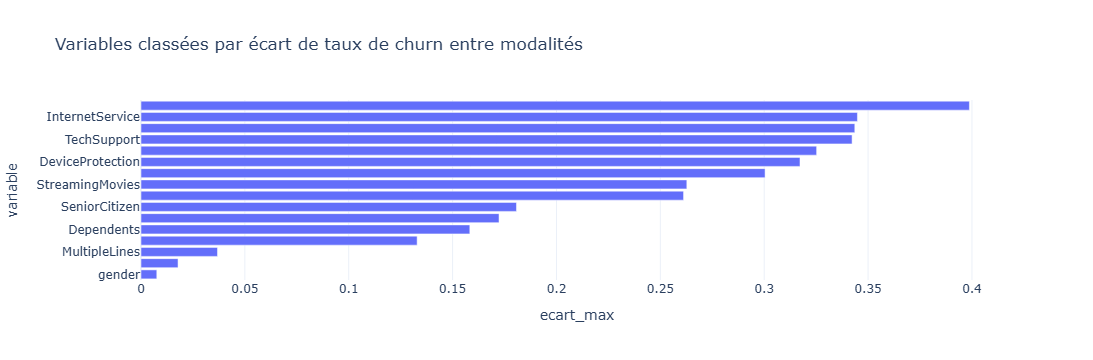

In [22]:
# Classement des variables selon l'écart maximal de leur taux de churn (variables les plus discriminantes)
spread = (rates.groupby("variable")["taux_churn"].agg(lambda s: s.max() - s.min())
          .sort_values(ascending=False).rename("ecart_max"))
fig = px.bar(spread.reset_index(), x="ecart_max", y="variable", orientation="h", template=TEMPLATE,
             title="Variables classées par écart de taux de churn entre modalités")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

In [23]:
# Modalités rares (effectif < 5 % du jeu) : à surveiller
rates[rates["effectif"] < 0.05 * len(df)]

,variable,modalite,taux_churn,effectif,ecart_vs_moyenne


**À observer :** `Contract`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaymentMethod` ont les plus grands écarts.
`gender` a un écart quasi nul : c'est un bon point pour l'analyse d'équité.
Les modalités « No internet service » sont répétées dans 6 colonnes (redondance avec `InternetService = No`).

## 7. Analyses croisées

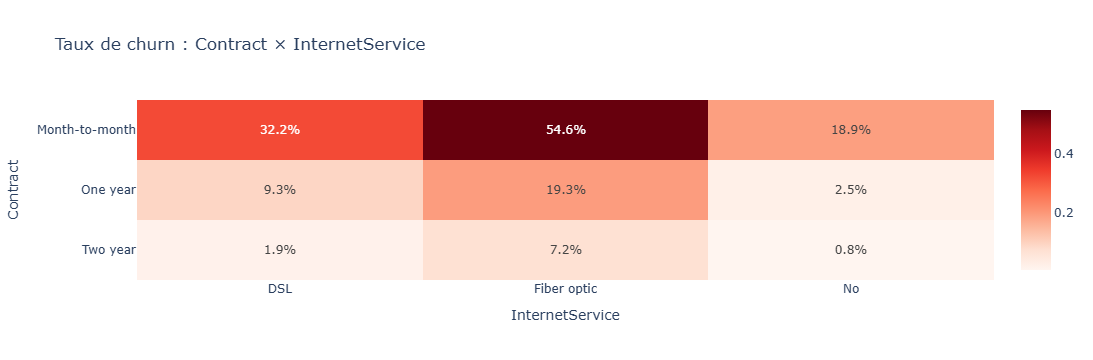

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,1223,2128,524
One year,570,539,364
Two year,628,429,638


In [24]:
# 7.1 Contract x InternetService : taux de churn
pivot = df.pivot_table(index="Contract", columns="InternetService", values="Churn", aggfunc="mean")
fig = px.imshow(pivot, text_auto=".1%", color_continuous_scale="Reds", aspect="auto",
                title="Taux de churn : Contract × InternetService", template=TEMPLATE)
fig.show()

# Effectifs correspondants (pour savoir si les cases sont fiables)
df.pivot_table(index="Contract", columns="InternetService", values="Churn", aggfunc="count")

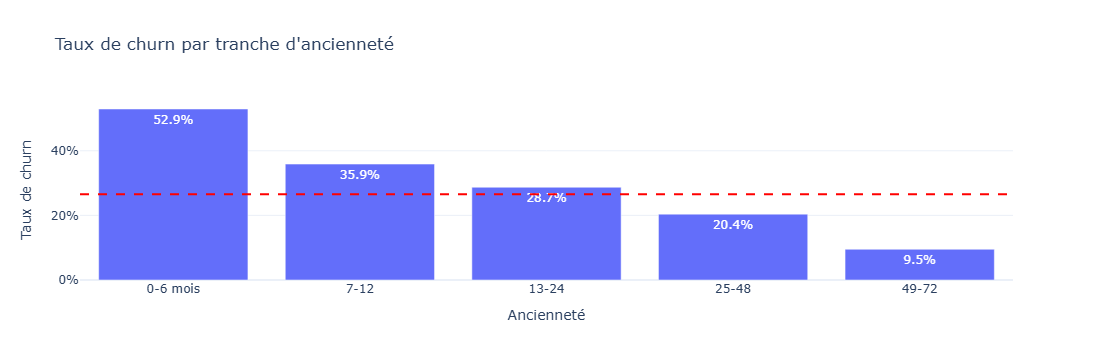

In [25]:
# 7.2 Tranches d'ancienneté
bins = [-1, 6, 12, 24, 48, 72]
labels = ["0-6 mois", "7-12", "13-24", "25-48", "49-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

t = df.groupby("tenure_group", observed=True)["Churn"].agg(["mean", "count"]).reset_index()
fig = px.bar(t, x="tenure_group", y="mean", text=t["mean"].map("{:.1%}".format), template=TEMPLATE,
             title="Taux de churn par tranche d'ancienneté",
             labels={"tenure_group": "Ancienneté", "mean": "Taux de churn"})
fig.add_hline(y=global_rate, line_dash="dash", line_color="red")
fig.update_yaxes(tickformat=".0%")
fig.show()

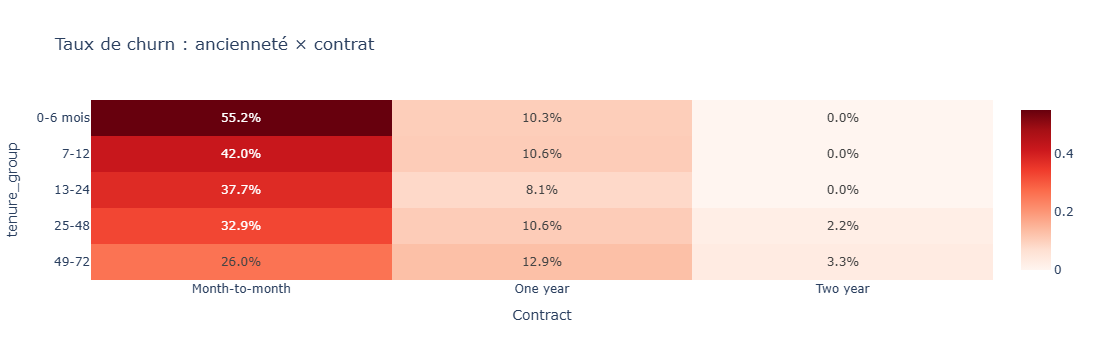

In [26]:
# 7.3 Ancienneté x type de contrat
pivot2 = df.pivot_table(index="tenure_group", columns="Contract", values="Churn", aggfunc="mean", observed=True)
fig = px.imshow(pivot2, text_auto=".1%", color_continuous_scale="Reds", aspect="auto",
                title="Taux de churn : ancienneté × contrat", template=TEMPLATE)
fig.show()

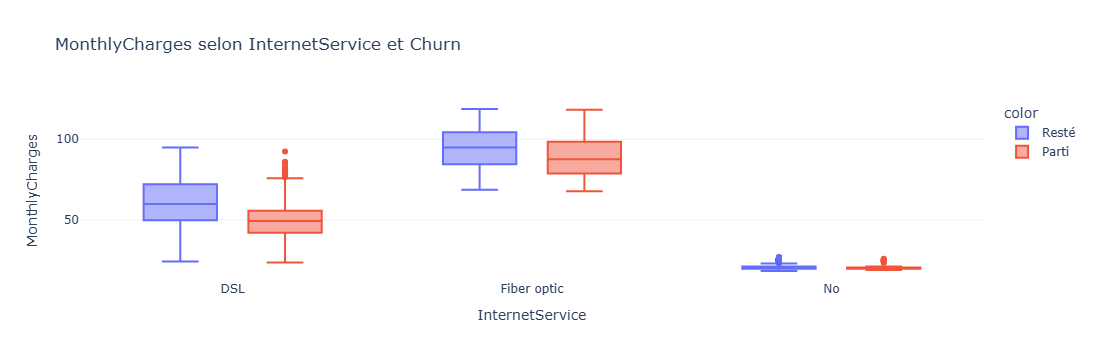

In [27]:
# 7.4 MonthlyCharges selon le type d'internet
fig = px.box(df, x="InternetService", y="MonthlyCharges",
             color=df["Churn"].map({0: "Resté", 1: "Parti"}), template=TEMPLATE,
             title="MonthlyCharges selon InternetService et Churn")
fig.show()

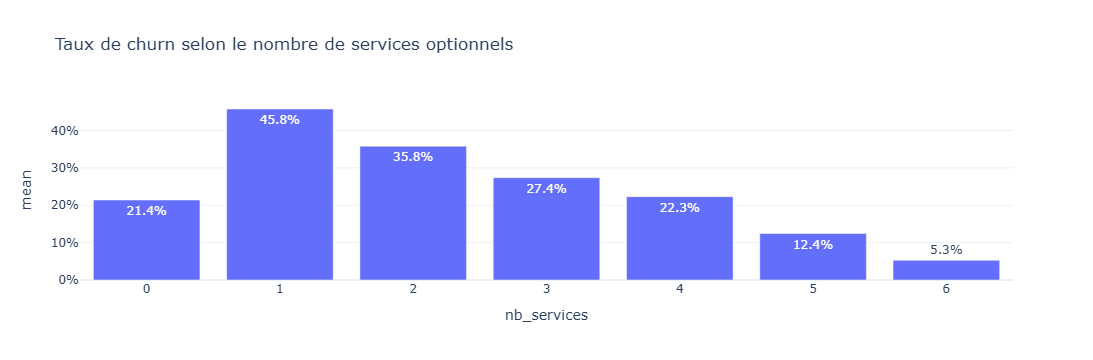

In [28]:
# 7.5 Nombre de services optionnels souscrits vs churn
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["nb_services"] = (df[services] == "Yes").sum(axis=1)
s = df.groupby("nb_services")["Churn"].agg(["mean", "count"]).reset_index()
fig = px.bar(s, x="nb_services", y="mean", text=s["mean"].map("{:.1%}".format), template=TEMPLATE,
             title="Taux de churn selon le nombre de services optionnels")
fig.update_yaxes(tickformat=".0%")
fig.show()

## 8. Synthèse de l'exploration

À compléter avec **tes propres chiffres** (utile pour le one-pager) :

| Constat | Chiffre observé | Décision de prétraitement |
|---|---|---|
| `TotalCharges` en texte, 11 valeurs vides | ... | `to_numeric` + imputation par 0 (`tenure = 0`) |
| `customerID` unique | ... | Supprimer |
| Classes déséquilibrées | ...% / ...% | Split stratifié, `class_weight`, métriques adaptées |
| `tenure` / `TotalCharges` corrélées | r = ... | Garder les deux ou en retirer une (à tester) |
| Contrat mensuel vs 2 ans | ...% vs ...% | Variable clé à conserver |
| Ancienneté 0-6 mois | ...% | Variable clé ; envisager `tenure_group` |
| Fibre optique | ...% | Variable clé |
| `gender` | écart ≈ ... | Garder (analyse d'équité) |
| « No internet service » répété | 6 colonnes | Regrouper en « No » (optionnel) |

**Prochaine étape :** `src/preprocess.py` (nettoyage, pipeline, split paramétrable).